# Install Libraries & Import Data

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [205]:
drive = "/content/drive/MyDrive/Personal Work/World Cup/"

matches = pd.read_csv(f"{drive}matches.csv")
matches_detail = pd.read_csv(f"{drive}matches_detailed.csv")
squads_player = pd.read_csv(f"{drive}squads_and_players.csv")
teams = pd.read_csv(f"{drive}teams.csv")
venue = pd.read_csv(f"{drive}venues.csv")
match_team_stats = pd.read_csv(f"{drive}match_team_stats.csv")
match_prediction_stats = pd.read_csv(f"{drive}match_prediction_features.csv")

# Feature Engineering


Train Set - Team Profiles Delta w Match info - Team 1 Win Probability




In [206]:
# Matches Data

matches_detail.columns

Index(['match_id', 'date', 'kickoff_time_utc', 'stage_name', 'stadium_name',
       'city', 'country', 'home_team_name', 'home_fifa_code', 'away_team_name',
       'away_fifa_code', 'home_score', 'away_score', 'home_penalty_score',
       'away_penalty_score', 'status', 'result_type', 'home_xg', 'away_xg',
       'home_goalkeeper', 'away_goalkeeper', 'player_of_the_match_name',
       'referee_name'],
      dtype='object')

In [207]:
df_matches = matches_detail[['match_id', 'date','home_team_name', 'home_fifa_code', 'away_team_name',
       'away_fifa_code', 'home_score', 'away_score', 'status', 'home_xg',
       'away_xg']]

In [208]:
df_matches['date'] = pd.to_datetime(df_matches['date'])

/tmp/ipykernel_1151/4180176266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matches['date'] = pd.to_datetime(df_matches['date'])


In [209]:
df_matches.head(75)

,match_id,date,home_team_name,home_fifa_code,away_team_name,away_fifa_code,home_score,away_score,status,home_xg,away_xg
0,1,2026-06-11,Mexico,MEX,South Africa,RSA,2.0,0.0,Completed,1.84,0.52
1,2,2026-06-11,South Korea,KOR,Czechia,CZE,2.0,1.0,Completed,1.45,1.12
2,3,2026-06-12,Canada,CAN,Bosnia and Herzegovina,BIH,1.0,1.0,Completed,1.35,0.98
3,4,2026-06-12,USA,USA,Paraguay,PAR,4.0,1.0,Completed,2.76,0.88
4,5,2026-06-13,Qatar,QAT,Switzerland,SUI,1.0,1.0,Completed,0.78,1.54
...,...,...,...,...,...,...,...,...,...,...,...
70,71,2026-06-28,Panama,PAN,England,ENG,0.0,2.0,Completed,0.69,1.39
71,72,2026-06-28,Croatia,CRO,Ghana,GHA,2.0,1.0,Completed,0.42,0.74
72,73,2026-06-29,South Africa,RSA,Canada,CAN,0.0,1.0,Completed,0.13,1.32
73,74,2026-06-29,Brazil,BRA,Japan,JPN,2.0,1.0,Completed,1.69,0.23


In [210]:
teams

,team_id,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name
0,1,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
1,2,South Africa,RSA,A,CAF,60,1620,Hugo Broos
2,3,South Korea,KOR,A,AFC,22,1800,Hong Myung-bo
3,4,Czechia,CZE,A,UEFA,40,1740,Miroslav Koubek
4,5,Canada,CAN,B,CONCACAF,33,1795,Jesse Marsch
5,6,Bosnia and Herzegovina,BIH,B,UEFA,64,1645,Sergej Barbarez
6,7,Qatar,QAT,B,AFC,56,1600,Julen Lopetegui
7,8,Switzerland,SUI,B,UEFA,19,1860,Murat Yakin
8,9,Brazil,BRA,C,CONMEBOL,6,2030,Carlo Ancelotti
9,10,Morocco,MAR,C,CAF,7,1920,Walid Regragui


In [211]:
#squads_grouped = squads_player.groupby(['team_id', 'position'])[['market_value_eur','caps', 'height_cm', 'goals']].mean()
squads_grouped = squads_player.groupby(['team_id'])[['market_value_eur','caps']].mean()

In [212]:
squads_grouped_df = squads_grouped.reset_index()
team_summary = pd.merge(squads_grouped_df, teams[['team_id', 'team_name', 'elo_rating']], how='inner', on='team_id')

In [213]:
numerical_cols = ['market_value_eur', 'caps']
team_summary[numerical_cols] = team_summary[numerical_cols].round(2)
display(team_summary)

,team_id,market_value_eur,caps,team_name,elo_rating
0,1,15842558.04,47.58,Mexico,1810
1,2,1834615.38,20.69,South Africa,1620
2,3,5348076.92,37.46,South Korea,1800
3,4,7197762.69,28.38,Czechia,1740
4,5,7855135.50,37.42,Canada,1795
5,6,5630769.23,23.58,Bosnia and Herzegovina,1645
6,7,4665383.69,61.00,Qatar,1600
7,8,13737866.08,44.15,Switzerland,1860
8,9,34355092.81,35.85,Brazil,2030
9,10,17567467.46,27.81,Morocco,1920


In [214]:
match_team_stats

,match_id,team_id,possession_pct,total_shots,shots_on_target,corners,fouls,offsides,saves,player_of_the_match,data_source,last_updated
0,1,1,57,16,4,6,11,2,1,Julián Andrés Quinones,fifa.com,2026-06-24
1,1,2,43,3,2,3,15,1,4,NaN,fifa.com,2026-06-24
2,2,3,54,12,5,4,10,1,2,Inbeom Hwang,sofascore.com,2026-06-24
3,2,4,46,10,3,3,13,2,4,NaN,sofascore.com,2026-06-24
4,3,5,52,13,4,9,12,2,3,Ismaël Kenneth Jordan Kone,fifa.com,2026-06-24
...,...,...,...,...,...,...,...,...,...,...,...,...
195,98,25,32,5,2,1,18,1,6,NaN,fifa.com,2026-07-11
196,99,36,47,13,5,7,10,1,6,NaN,Sofascore,2026-07-12
197,99,45,53,14,8,4,8,5,4,Jude Victor William Bellingham,Sofascore,2026-07-12
198,100,37,59,23,7,8,14,4,4,Julián Alvarez,Sofascore,2026-07-12


In [215]:
df_matches_group = df_matches[(df_matches['status'] == 'Completed') & (df_matches['date'] < '2026-06-29')]

# Building Team Profiles

*   df_matches_group - All Group Stage Matches
*   team_summary - team features
*   match_team_stats - game stats



In [216]:
team_summary.head(5)

,team_id,market_value_eur,caps,team_name,elo_rating
0,1,15842558.04,47.58,Mexico,1810
1,2,1834615.38,20.69,South Africa,1620
2,3,5348076.92,37.46,South Korea,1800
3,4,7197762.69,28.38,Czechia,1740
4,5,7855135.50,37.42,Canada,1795


In [217]:
df_matches_group

,match_id,date,home_team_name,home_fifa_code,away_team_name,away_fifa_code,home_score,away_score,status,home_xg,away_xg
0,1,2026-06-11,Mexico,MEX,South Africa,RSA,2.0,0.0,Completed,1.84,0.52
1,2,2026-06-11,South Korea,KOR,Czechia,CZE,2.0,1.0,Completed,1.45,1.12
2,3,2026-06-12,Canada,CAN,Bosnia and Herzegovina,BIH,1.0,1.0,Completed,1.35,0.98
3,4,2026-06-12,USA,USA,Paraguay,PAR,4.0,1.0,Completed,2.76,0.88
4,5,2026-06-13,Qatar,QAT,Switzerland,SUI,1.0,1.0,Completed,0.78,1.54
...,...,...,...,...,...,...,...,...,...,...,...
67,68,2026-06-27,Algeria,ALG,Austria,AUT,3.0,3.0,Completed,1.62,1.44
68,69,2026-06-28,Colombia,COL,Portugal,POR,0.0,0.0,Completed,1.62,0.73
69,70,2026-06-28,Congo DR,COD,Uzbekistan,UZB,3.0,1.0,Completed,2.35,0.20
70,71,2026-06-28,Panama,PAN,England,ENG,0.0,2.0,Completed,0.69,1.39


In [218]:
match_team_stats.head(5)

,match_id,team_id,possession_pct,total_shots,shots_on_target,corners,fouls,offsides,saves,player_of_the_match,data_source,last_updated
0,1,1,57,16,4,6,11,2,1,Julián Andrés Quinones,fifa.com,2026-06-24
1,1,2,43,3,2,3,15,1,4,NaN,fifa.com,2026-06-24
2,2,3,54,12,5,4,10,1,2,Inbeom Hwang,sofascore.com,2026-06-24
3,2,4,46,10,3,3,13,2,4,NaN,sofascore.com,2026-06-24
4,3,5,52,13,4,9,12,2,3,Ismaël Kenneth Jordan Kone,fifa.com,2026-06-24


In [219]:
# Establish Group Stage features -

df_matches_group_home = pd.merge(df_matches_group, team_summary, how='inner', left_on='home_team_name', right_on='team_name', suffixes=('', '_home'))

df_matches_group_ha = pd.merge(df_matches_group_home, team_summary, how='inner',left_on='away_team_name', right_on='team_name', suffixes=('', '_away'))


In [220]:
# Home Team Calculations
df_matches_group_ha['adjusted_offensive_home_elo'] = df_matches_group_ha['elo_rating_away'] * df_matches_group_ha['home_xg']
df_matches_group_ha['adjusted_offensive_away_elo'] = df_matches_group_ha['elo_rating'] * df_matches_group_ha['away_xg']
df_matches_group_ha['home_defensive_efficiency'] = df_matches_group_ha['elo_rating'] * df_matches_group_ha['away_xg']
df_matches_group_ha['away_defensive_efficiency'] = df_matches_group_ha['elo_rating_away'] * df_matches_group_ha['home_xg']



In [221]:
df_matches_group_ha[df_matches_group_ha['home_team_name'] == 'Spain']

,match_id,date,home_team_name,home_fifa_code,away_team_name,away_fifa_code,home_score,away_score,status,home_xg,...,elo_rating,team_id_away,market_value_eur_away,caps_away,team_name_away,elo_rating_away,adjusted_offensive_home_elo,adjusted_offensive_away_elo,home_defensive_efficiency,away_defensive_efficiency
12,13,2026-06-15,Spain,ESP,Cabo Verde,CPV,0.0,0.0,Completed,2.15,...,2120,30,3666401.96,32.35,Cabo Verde,1640,3526.0,742.0,742.0,3526.0
38,39,2026-06-21,Spain,ESP,Saudi Arabia,KSA,4.0,0.0,Completed,3.28,...,2120,31,4982354.27,36.27,Saudi Arabia,1660,5444.8,530.0,530.0,5444.8


In [222]:
df_matches_group_ha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   match_id                     72 non-null     int64         
 1   date                         72 non-null     datetime64[ns]
 2   home_team_name               72 non-null     object        
 3   home_fifa_code               72 non-null     object        
 4   away_team_name               72 non-null     object        
 5   away_fifa_code               72 non-null     object        
 6   home_score                   72 non-null     float64       
 7   away_score                   72 non-null     float64       
 8   status                       72 non-null     object        
 9   home_xg                      72 non-null     float64       
 10  away_xg                      72 non-null     float64       
 11  team_id                      72 non-null     in

In [223]:
# Now I have my features prepped, I need to combine the home & away data to find the averages for the team profiles

# 1. Home Profile to Normal
home_profile = {
    'home_team_name': 'team',
    'market_value_eur': 'market_value',
    'caps': 'int_caps',
    'adjusted_offensive_home_elo': 'adj_off_elo',
    'home_defensive_efficiency': 'def_elo'
}


home_df = df_matches_group_ha[list(home_profile.keys())].rename(columns=home_profile)

# 2. Away Profile to Normal

away_profile = {
    'away_team_name': 'team',
    'market_value_eur_away': 'market_value',
    'caps_away': 'int_caps',
    'adjusted_offensive_away_elo': 'adj_off_elo',
    'away_defensive_efficiency': 'def_elo'
}


away_df = df_matches_group_ha[list(away_profile.keys())].rename(columns=away_profile)


# 3. Stack the profiles

stacked_stats = pd.concat([home_df, away_df], axis=0, ignore_index=True)

In [224]:
stacked_stats

,team,market_value,int_caps,adj_off_elo,def_elo
0,Mexico,15842558.04,47.58,2980.80,941.2
1,South Korea,5348076.92,37.46,2523.00,2016.0
2,Canada,7855135.50,37.42,2220.75,1759.1
3,USA,14569694.04,37.58,4761.00,1628.0
4,Qatar,4665383.69,61.00,1450.80,2464.0
...,...,...,...,...,...
139,Austria,9381470.88,39.23,2534.40,2964.6
140,Portugal,44073414.04,45.23,1452.70,3256.2
141,Uzbekistan,3274038.46,37.38,334.00,3877.5
142,England,50839188.31,32.81,2335.20,1414.5


In [225]:
# Now Finalize the profiles

team_profiles = stacked_stats.groupby('team').agg({
      'adj_off_elo': 'mean',
      'def_elo': 'mean',
      'market_value': 'mean',
      'int_caps': 'mean'

})

In [226]:
team_profiles

,adj_off_elo,def_elo,market_value,int_caps
team,,,,
Algeria,2319.600000,2915.733333,8813110.00,30.50
Argentina,3783.566667,1239.833333,39424594.00,48.73
Australia,1351.466667,1479.733333,3078418.96,28.88
Austria,2301.566667,2610.800000,9381470.88,39.23
Belgium,3426.633333,1443.000000,24387152.73,42.35
Bosnia and Herzegovina,1921.300000,2604.583333,5630769.23,23.58
Brazil,2878.266667,1657.833333,34355092.81,35.85
Cabo Verde,1198.400000,2285.066667,3666401.96,32.35
Canada,3614.583333,1142.816667,7855135.50,37.42


# Build Training Set

In [227]:
df_matches

,match_id,date,home_team_name,home_fifa_code,away_team_name,away_fifa_code,home_score,away_score,status,home_xg,away_xg
0,1,2026-06-11,Mexico,MEX,South Africa,RSA,2.0,0.0,Completed,1.84,0.52
1,2,2026-06-11,South Korea,KOR,Czechia,CZE,2.0,1.0,Completed,1.45,1.12
2,3,2026-06-12,Canada,CAN,Bosnia and Herzegovina,BIH,1.0,1.0,Completed,1.35,0.98
3,4,2026-06-12,USA,USA,Paraguay,PAR,4.0,1.0,Completed,2.76,0.88
4,5,2026-06-13,Qatar,QAT,Switzerland,SUI,1.0,1.0,Completed,0.78,1.54
...,...,...,...,...,...,...,...,...,...,...,...
99,100,2026-07-12,Argentina,ARG,Switzerland,SUI,3.0,1.0,Completed,2.00,0.53
100,101,2026-07-14,France,FRA,Spain,ESP,NaN,NaN,Scheduled,NaN,NaN
101,102,2026-07-15,England,ENG,Argentina,ARG,NaN,NaN,Scheduled,NaN,NaN
102,103,2026-07-18,NaN,NaN,NaN,NaN,NaN,NaN,Scheduled,NaN,NaN


In [228]:
# Create the raw matchup row
final_match = pd.DataFrame({
    'match_id': [103],
    'status': ['scheduled'],
    'home_team_name': ['Argentina'],
    'away_team_name': ['Spain'],
    'date': ['2026-07-19']
})



# Append it to your main matchups DataFrame
df_matches = pd.concat([df_matches, final_match], ignore_index=True)

df_matches['date'] = pd.to_datetime(df_matches['date'])

In [229]:
df_matches_knockout = df_matches[df_matches['date'] >= pd.to_datetime('2026-06-29')]

In [230]:
team_profiles

,adj_off_elo,def_elo,market_value,int_caps
team,,,,
Algeria,2319.600000,2915.733333,8813110.00,30.50
Argentina,3783.566667,1239.833333,39424594.00,48.73
Australia,1351.466667,1479.733333,3078418.96,28.88
Austria,2301.566667,2610.800000,9381470.88,39.23
Belgium,3426.633333,1443.000000,24387152.73,42.35
Bosnia and Herzegovina,1921.300000,2604.583333,5630769.23,23.58
Brazil,2878.266667,1657.833333,34355092.81,35.85
Cabo Verde,1198.400000,2285.066667,3666401.96,32.35
Canada,3614.583333,1142.816667,7855135.50,37.42


In [231]:
df_matches_knockout['xg_delta'] = df_matches_knockout['home_xg'] - df_matches_knockout['away_xg']

/tmp/ipykernel_1151/3567397507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matches_knockout['xg_delta'] = df_matches_knockout['home_xg'] - df_matches_knockout['away_xg']


In [232]:
# Filter for results
ko = df_matches_knockout[['home_team_name', 'away_team_name', 'xg_delta']]

In [233]:
# Join home/away teams

home_teams = pd.merge(ko, team_profiles, how='inner', left_on='home_team_name', right_on='team', suffixes=('', '_home'))
both_teams = pd.merge(home_teams, team_profiles, how='inner', left_on='away_team_name', right_on='team', suffixes=('', '_away'))

In [234]:
both_teams.columns

Index(['home_team_name', 'away_team_name', 'xg_delta', 'adj_off_elo',
       'def_elo', 'market_value', 'int_caps', 'adj_off_elo_away',
       'def_elo_away', 'market_value_away', 'int_caps_away'],
      dtype='object')

In [235]:
# Build delta features
both_teams['adj_off_elo_delta'] = both_teams['adj_off_elo'] - both_teams['adj_off_elo_away']
both_teams['def_elo_delta'] = both_teams['def_elo'] - both_teams['def_elo_away']
both_teams['market_value_delta'] = both_teams['market_value'] - both_teams['market_value_away']
both_teams['int_caps_delta'] = both_teams['int_caps'] - both_teams['int_caps_away']

df_train = both_teams[['home_team_name', 'away_team_name', 'adj_off_elo_delta', 'def_elo_delta', 'market_value_delta', 'int_caps_delta', 'xg_delta']]


In [236]:
# Ready to Train

# 1. Set the team names as a MultiIndex
df_train = df_train.set_index(['home_team_name', 'away_team_name'])

df_train

,,adj_off_elo_delta,def_elo_delta,market_value_delta,int_caps_delta,xg_delta
home_team_name,away_team_name,,,,,
South Africa,Canada,-1877.850000,1330.383333,-6020520.12,-16.73,-1.19
Brazil,Japan,-778.933333,-378.833333,23937785.12,4.20,1.46
Germany,Paraguay,3438.633333,-490.733333,32809919.34,5.96,0.30
Netherlands,Morocco,2282.316667,-183.200000,11863976.62,5.92,-1.17
Côte d'Ivoire,Norway,-1644.833333,-26.000000,1139096.92,-3.65,-0.87
France,Sweden,310.766667,-1276.750000,43757000.92,10.96,2.50
Mexico,Ecuador,334.700000,-374.366667,5889200.81,17.39,0.29
England,Congo DR,849.866667,196.333333,44953117.62,1.81,1.28
Belgium,Senegal,180.533333,-1335.400000,6835417.46,2.66,-1.84


# Train

In [237]:
# Import libs

import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [258]:
# Split the train and test data

train_df = df_train[df_train['xg_delta'].notna()].copy()
predict_df = df_train[df_train['xg_delta'].isna()].copy()


#split_index = int(len(df_train) * .5)

#train_df = df_train[:split_index].copy()
#predict_df = df_train[split_index:].copy()

In [259]:
# Feature col

feature_cols = ['adj_off_elo_delta', 'def_elo_delta', 'market_value_delta', 'int_caps_delta']
target_col = 'xg_delta'


# set up training data

X_train = train_df[feature_cols]
y_train = train_df[target_col]


# set up testing data

X_predict = predict_df[feature_cols]






In [260]:
# Scale the features so the have the same effect on the predictor

scaler = StandardScaler()

# Fit the Scaler on the training data

X_train_scaled = scaler.fit_transform(X_train)
X_predict_scaled = scaler.transform(X_predict)

In [261]:
# Train Model

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

Ridge()

In [262]:
# make predictions

predictions = model.predict(X_predict_scaled)


# Print Output

results = pd.DataFrame(index=X_predict.index)
results['Predicted_Delta_xG'] = predictions

print(results)

                               Predicted_Delta_xG
home_team_name away_team_name                    
France         Spain                    -0.954021
England        Argentina                -0.620186
Argentina      Spain                    -0.796864


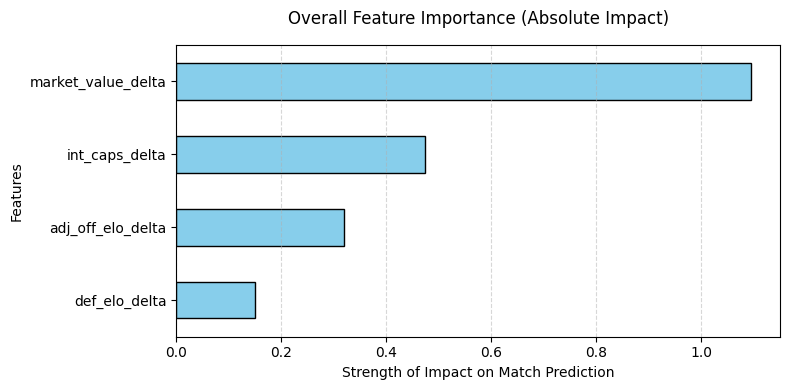

In [263]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Put the absolute weights and feature names into a Pandas Series
# We use .abs() so all bars represent pure "importance" pointing to the right
importance = pd.Series(model.coef_, index=feature_cols).abs()

# 2. Sort them so the most important feature is at the top
importance = importance.sort_values(ascending=True)

# 3. Create a clean, spacious horizontal bar chart
plt.figure(figsize=(8, 4))  # Sets a clean aspect ratio
importance.plot(kind='barh', color='skyblue', edgecolor='black')

# 4. Clean up the labels and layout so nothing overlaps
plt.title('Overall Feature Importance (Absolute Impact)', fontsize=12, pad=15)
plt.xlabel('Strength of Impact on Match Prediction', fontsize=10)
plt.ylabel('Features', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)  # Add light vertical gridlines
plt.tight_layout()  # Automatically adjusts margins so no labels or bars overlap!

# 5. Display the plot
plt.show()